In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def ErrLogLike(N,M):
    return np.sqrt(M/N)/(np.sqrt(N - M))
def N_finder(M, e):
    return M/2 + np.sqrt(np.power(e**2*M,2) + 4*e**2*M)/(2*e**2)

C:\Users\pxt561\AppData\Local\Temp\ipykernel_25656\3926543033.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt(M/N)/(np.sqrt(N - M))


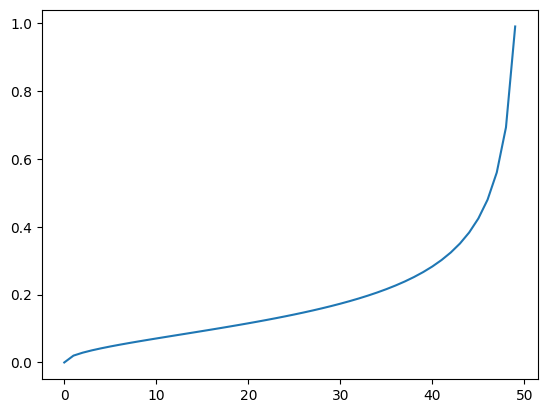

In [3]:
M = np.arange(0,51)
plt.plot(M, ErrLogLike(50,M))

In [4]:
def Optimize_err(N,M,e):
    """Starting from N_i and M_i, finds the optimal number of N_f to obtain log_L with an error within e."""
    N_arr = []
    err_arr = []
    for v in M:
        N_i = N
        M_i = v
        err = ErrLogLike(N_i,M_i)
        while e < err:
            C_i = M_i/N_i
            N_ip1 = N_finder(M_i,e)
            M_ip1 = N_ip1*C_i
            err = ErrLogLike(N_ip1,M_ip1)
            if np.abs(N_ip1 - N_i) < 0.001:
                N_i = N_ip1
                M_i = M_ip1
                break
            N_i = N_ip1
            M_i = M_ip1
        N_arr.append(int(np.ceil(N_i)))
        err_arr.append(err)
    return N_arr, err_arr
    

In [17]:
def approx_err(M,e):
    return np.ceil(M/50/(e**2*(1-M/50)))

In [16]:
approx_err(M,0.095)

array([ 52.14274075,  57.08050029,  62.32686981,  67.91171477,
        73.86888273,  80.23688987,  87.05975465,  94.38801683,
       102.27999148, 110.8033241 , 120.03693444, 130.07346742,
       141.02241249, 153.01411423, 166.20498615, 180.7843709 ,
       196.98368729, 215.08880561, 235.45706371, 258.54108957,
       284.9228334 , 315.36330705, 350.87719298, 392.84814908,
       443.2132964 , 504.77069868, 581.71745152, 680.6489909 ,
       812.55771006, 997.2299169 ])

Text(0, 0.5, 'N_f')

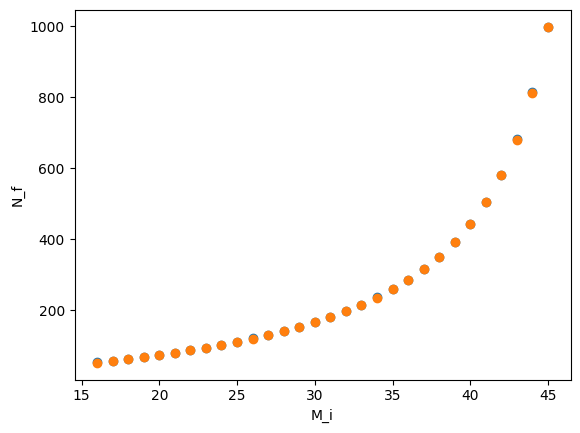

In [11]:
M = np.arange(16,46)
plt.scatter(M,Optimize_err(50,M,0.095)[0])
plt.scatter(M, approx_err(M,0.095))
plt.xlabel('M_i')
plt.ylabel('N_f')

In [129]:
np.savetxt('Num_Reals_to_init_50_e_0095', Optimize_err(50,M,0.095)[0])

TypeError: savetxt() got an unexpected keyword argument 'dtype'

In [125]:
len(Optimize_err(50,M,0.095)[0])

30

In [130]:
NtM = np.loadtxt('Num_Reals_to_init_50_e_0095', dtype = int)

C:\Users\pxt561\AppData\Local\Temp\ipykernel_32076\3893920085.py:1: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  NtM = np.loadtxt('Num_Reals_to_init_50_e_0095', dtype = int)


In [136]:
NtM[45-16]

998